# Structural Analysis: TGFbeta Mimic vs AlphaFold Protein

## Overview

This notebook demonstrates a comprehensive structural analysis workflow to compare a solved protein structure with an AlphaFold prediction. Specifically, we will:

1. **Load and parse structures**: Extract the TGFbeta mimic (9E9G chain B) and TGFBR2 receptor (9E9G chain A) from the solved structure, and load the AlphaFold protein structure
2. **Perform structural alignment**: Align the TGFbeta mimic with the AlphaFold structure and calculate RMSD values
3. **Identify binding interface**: Find residues in the TGFbeta mimic that interact with TGFBR2
4. **Analyze conservation**: Determine if binding interface residues are conserved in the AlphaFold structure
5. **Visualize results**: Create interactive 3D visualizations and conservation plots

## Background

- **9E9G**: Solved structure of a TGFbeta mimic from a parasite in complex with human TGFBR2
  - Chain A: TGFBR2 receptor
  - Chain B: TGFbeta mimic
- **AF-A0A0K0K0F9-F1-model_v4.pdb**: AlphaFold prediction of a related protein (BM9777 from Brugia malayi)

**Research Question**: Does the AlphaFold protein likely bind TGFBR2 based on conservation of binding interface residues?

---

## Table of Contents
1. [Setup and Imports](#setup)
2. [Structure Loading and Parsing](#loading)
3. [Structural Alignment](#alignment)
4. [Interface Analysis](#interface)
5. [Conservation Analysis](#conservation)
6. [Visualization](#visualization)
7. [Summary and Conclusions](#summary)


## 1. Setup and Imports {#setup}

First, we import all necessary libraries for structural analysis. This includes BioPython for structure manipulation, numpy for numerical operations, matplotlib for plotting, and py3Dmol for interactive 3D visualization.


In [1]:
# Core scientific computing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cdist

# BioPython for structural biology
from Bio.PDB import MMCIFParser, PDBParser, Superimposer, PDBIO
from Bio.PDB.cealign import CEAligner
from Bio.SeqUtils import seq1

# Visualization
import py3Dmol
from IPython.display import display, HTML

import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2. Structure Loading and Parsing {#loading}

In this section, we define helper functions for loading and processing protein structures, then load our target structures.

### Helper Functions

We'll create reusable functions for:
- Loading structures from different file formats (CIF and PDB)
- Extracting specific chains
- Getting atomic coordinates
- Calculating basic structure statistics


In [2]:
def load_structure(file_path, structure_id=None):
    """
    Load a protein structure from CIF or PDB file.
    
    Parameters:
    -----------
    file_path : str
        Path to the structure file
    structure_id : str, optional
        Custom structure ID. If None, uses filename without extension.
    
    Returns:
    --------
    Bio.PDB.Structure.Structure
        Loaded structure object
    """
    if structure_id is None:
        structure_id = file_path.split('/')[-1].split('.')[0]
    
    if file_path.endswith('.cif'):
        parser = MMCIFParser(QUIET=True)
    elif file_path.endswith('.pdb'):
        parser = PDBParser(QUIET=True)
    else:
        raise ValueError("File must be .cif or .pdb format")
    
    structure = parser.get_structure(structure_id, file_path)
    return structure

def get_chain(structure, chain_id):
    """
    Extract a specific chain from a structure.
    
    Parameters:
    -----------
    structure : Bio.PDB.Structure.Structure
        Structure object
    chain_id : str
        Chain identifier
    
    Returns:
    --------
    Bio.PDB.Chain.Chain
        Chain object
    """
    for model in structure:
        for chain in model:
            if chain.id == chain_id:
                return chain
    raise ValueError(f"Chain {chain_id} not found in structure")

def get_ca_atoms(chain):
    """
    Extract alpha carbon (CA) atoms and their residues from a chain.
    
    Parameters:
    -----------
    chain : Bio.PDB.Chain.Chain
        Chain object
    
    Returns:
    --------
    tuple
        (ca_atoms_list, residues_list, coordinates_array)
    """
    ca_atoms = []
    residues = []
    
    for residue in chain:
        # Skip heteroatoms and water
        if residue.id[0] == ' ':
            if 'CA' in residue:
                ca_atoms.append(residue['CA'])
                residues.append(residue)
    
    coordinates = np.array([atom.coord for atom in ca_atoms])
    return ca_atoms, residues, coordinates

def get_all_atoms(chain):
    """
    Extract all atoms from a chain.
    
    Parameters:
    -----------
    chain : Bio.PDB.Chain.Chain
        Chain object
    
    Returns:
    --------
    tuple
        (atoms_list, residues_list, coordinates_array)
    """
    atoms = []
    residues = []
    
    for residue in chain:
        # Skip heteroatoms and water
        if residue.id[0] == ' ':
            for atom in residue:
                atoms.append(atom)
                residues.append(residue)
    
    coordinates = np.array([atom.coord for atom in atoms])
    return atoms, residues, coordinates

def get_structure_info(structure):
    """
    Get basic information about a structure.
    
    Parameters:
    -----------
    structure : Bio.PDB.Structure.Structure
        Structure object
    
    Returns:
    --------
    dict
        Dictionary with structure information
    """
    info = {
        'structure_id': structure.id,
        'models': len(list(structure)),
        'chains': {},
        'total_residues': 0
    }
    
    for model in structure:
        for chain in model:
            chain_residues = len([r for r in chain if r.id[0] == ' '])
            info['chains'][chain.id] = chain_residues
            info['total_residues'] += chain_residues
    
    return info

print("✅ Helper functions defined successfully!")


✅ Helper functions defined successfully!


In [3]:
# Define file paths
file_9e9g = '/n/holylabs/chenf2011_lab/Lab/blake/private/mining_agent/tools/analysis_toolsandexamples/9E9G.cif'
file_af = '/n/holylabs/chenf2011_lab/Lab/blake/private/mining_agent/tools/analysis_toolsandexamples/AF-A0A0K0K0F9-F1-model_v4.pdb'

# Load the structures
print("Loading structures...")
structure_9e9g = load_structure(file_9e9g)
structure_af = load_structure(file_af)
print("✅ Structures loaded successfully!")

# Get structure information
info_9e9g = get_structure_info(structure_9e9g)
info_af = get_structure_info(structure_af)

print("\n📊 Structure Information:")
print(f"\n9E9G: {info_9e9g['total_residues']} total residues across {len(info_9e9g['chains'])} chains")
for chain_id, n_residues in info_9e9g['chains'].items():
    print(f"  Chain {chain_id}: {n_residues} residues")

print(f"\nAlphaFold: {info_af['total_residues']} total residues across {len(info_af['chains'])} chains")
for chain_id, n_residues in info_af['chains'].items():
    print(f"  Chain {chain_id}: {n_residues} residues")


Loading structures...
✅ Structures loaded successfully!

📊 Structure Information:

9E9G: 193 total residues across 2 chains
  Chain A: 110 residues
  Chain B: 83 residues

AlphaFold: 97 total residues across 1 chains
  Chain A: 97 residues


In [4]:
# Extract chains and coordinates
print("Extracting chains and coordinates...")

# Get TGFbeta mimic (chain B from 9E9G)
chain_mimic = get_chain(structure_9e9g, 'B')
ca_atoms_mimic, residues_mimic, coords_mimic = get_ca_atoms(chain_mimic)
print(f"✅ TGFbeta mimic (chain B): {len(residues_mimic)} residues, {len(ca_atoms_mimic)} CA atoms")

# Get TGFBR2 receptor (chain A from 9E9G)
chain_receptor = get_chain(structure_9e9g, 'A')
ca_atoms_receptor, residues_receptor, coords_receptor = get_ca_atoms(chain_receptor)
print(f"✅ TGFBR2 receptor (chain A): {len(residues_receptor)} residues, {len(ca_atoms_receptor)} CA atoms")

# Get AlphaFold structure (chain A)
chain_af = get_chain(structure_af, 'A')
ca_atoms_af, residues_af, coords_af = get_ca_atoms(chain_af)
print(f"✅ AlphaFold protein (chain A): {len(residues_af)} residues, {len(ca_atoms_af)} CA atoms")

print(f"\n📏 Coordinate array shapes:")
print(f"  TGFbeta mimic: {coords_mimic.shape}")
print(f"  TGFBR2 receptor: {coords_receptor.shape}")
print(f"  AlphaFold protein: {coords_af.shape}")


Extracting chains and coordinates...
✅ TGFbeta mimic (chain B): 83 residues, 83 CA atoms
✅ TGFBR2 receptor (chain A): 110 residues, 110 CA atoms
✅ AlphaFold protein (chain A): 97 residues, 97 CA atoms

📏 Coordinate array shapes:
  TGFbeta mimic: (83, 3)
  TGFBR2 receptor: (110, 3)
  AlphaFold protein: (97, 3)


### Alignment Strategy

We use **structure-based alignment** rather than sequence alignment:

1. **Load structures**: Load both PDB structures into memory
2. **CEalign**: Use BioPython's CEAligner (Combinatorial Extension) algorithm to align structures based on 3D geometry
3. **Extract aligned pairs**: Identify residue pairs that are structurally aligned (CA atoms within 3.8Å)
4. **Calculate RMSD**: Measure structural similarity from the alignment

**Why CEalign?** Structure-based alignment (CEalign) aligns proteins based on their 3D atomic coordinates and geometric features, independent of sequence similarity. This is crucial for comparing structures that may have low sequence identity but similar folds, or for identifying structurally conserved regions that sequence alignment might miss.


In [5]:
def perform_structural_alignment_cealign(structure1, structure2, chain1_id, chain2_id):
    """
    Perform structure-based alignment using BioPython's CEAligner.
    CEalign (Combinatorial Extension) aligns structures based on 3D geometry,
    independent of sequence similarity.
    
    Parameters:
    -----------
    structure1, structure2 : Bio.PDB.Structure
        BioPython structure objects
    chain1_id, chain2_id : str
        Chain identifiers to align
    
    Returns:
    --------
    tuple
        (aligned_residue_pairs, rmsd, n_aligned)
        aligned_residue_pairs: list of tuples (residue1, residue2, idx1, idx2)
    """
    # Initialize CEAligner
    aligner = CEAligner()
    
    # Set reference structure (structure1)
    aligner.set_reference(structure1)
    
    # Align structure2 to structure1
    aligner.align(structure2, transform=True)
    
    # Get the chains
    chain1 = structure1[0][chain1_id]
    chain2 = structure2[0][chain2_id]
    
    # Get residues (only standard residues)
    residues1 = [res for res in chain1 if res.id[0] == ' ']
    residues2 = [res for res in chain2 if res.id[0] == ' ']
    
    # After CEalign transformation, find aligned residues by CA atom distance
    # Residues with CA atoms within 3.8Å after alignment are considered aligned
    aligned_pairs = []
    
    for idx1, res1 in enumerate(residues1):
        if 'CA' not in res1:
            continue
        ca1 = res1['CA'].get_coord()
        
        min_dist = float('inf')
        closest_idx = None
        closest_res = None
        
        for idx2, res2 in enumerate(residues2):
            if 'CA' not in res2:
                continue
            ca2 = res2['CA'].get_coord()
            
            # Calculate distance
            dist = np.linalg.norm(ca1 - ca2)
            
            if dist < min_dist:
                min_dist = dist
                closest_idx = idx2
                closest_res = res2
        
        # If closest residue is within 3.8Å, consider it aligned
        if min_dist < 3.8 and closest_res is not None:
            aligned_pairs.append((res1, closest_res, idx1, closest_idx))
    
    # Calculate RMSD for aligned CA atoms
    ca_coords1 = np.array([pair[0]['CA'].get_coord() for pair in aligned_pairs if 'CA' in pair[0]])
    ca_coords2 = np.array([pair[1]['CA'].get_coord() for pair in aligned_pairs if 'CA' in pair[1]])
    
    if len(ca_coords1) > 0:
        rmsd = np.sqrt(np.mean(np.sum((ca_coords1 - ca_coords2)**2, axis=1)))
    else:
        rmsd = 0.0
    
    n_aligned = len(aligned_pairs)
    
    return aligned_pairs, rmsd, n_aligned

print("✅ Structure-based alignment functions defined (using BioPython CEAligner)!")

✅ Structure-based alignment functions defined (using BioPython CEAligner)!


In [6]:
# Perform structure-based alignment using CEalign
print("="*70)
print("Performing structure-based alignment (CEalign)...")
print("Note: CEalign aligns based on 3D geometry, NOT sequence similarity")
print("="*70)

aligned_pairs, rmsd, n_aligned = perform_structural_alignment_cealign(
    structure_9e9g,  # ✅ This is a Structure object
    structure_af,
    'B',  # TGFbeta mimic chain
    'A'   # AlphaFold chain
)

print(f"\n✅ Structure-based alignment completed!")
print(f"   RMSD: {rmsd:.3f} Å")
print(f"   Number of aligned residues: {n_aligned}")
print(f"   Number of aligned pairs found: {len(aligned_pairs)}")

# Display some aligned pairs
print(f"\n📝 Sample of aligned residue pairs (first 10):")
for i, (res1, res2, idx1, idx2) in enumerate(aligned_pairs[:10]):
    print(f"   {res1.resname:3s} {res1.id[1]:3d} (mimic) <-> {res2.resname:3s} {res2.id[1]:3d} (AF)")


Performing structure-based alignment (CEalign)...
Note: CEalign aligns based on 3D geometry, NOT sequence similarity

✅ Structure-based alignment completed!
   RMSD: 2.076 Å
   Number of aligned residues: 59
   Number of aligned pairs found: 59

📝 Sample of aligned residue pairs (first 10):
   SER  16 (mimic) <-> ALA  28 (AF)
   SER  17 (mimic) <-> PRO  29 (AF)
   CYS  18 (mimic) <-> CYS  30 (AF)
   PRO  19 (mimic) <-> SER  31 (AF)
   PRO  20 (mimic) <-> PRO  32 (AF)
   LEU  21 (mimic) <-> PRO  33 (AF)
   PRO  22 (mimic) <-> LYS  34 (AF)
   ASP  23 (mimic) <-> LEU  35 (AF)
   ASP  24 (mimic) <-> ALA  36 (AF)
   VAL  27 (mimic) <-> PRO  38 (AF)


In [7]:
# Perform structural superposition using BioPython's Superimposer
print("Performing structural superposition...")

# Extract CA atoms for aligned residue pairs
fixed_atoms = []  # TGFbeta mimic
moving_atoms = []  # AlphaFold structure

for res_mimic, res_af, _, _ in aligned_pairs:
    if 'CA' in res_mimic and 'CA' in res_af:
        fixed_atoms.append(res_mimic['CA'])
        moving_atoms.append(res_af['CA'])

print(f"Using {len(fixed_atoms)} CA atom pairs for superposition")

# Perform superposition
super_imposer = Superimposer()
super_imposer.set_atoms(fixed_atoms, moving_atoms)

# Get RMSD
rmsd = super_imposer.rms
print(f"\n✅ Structural alignment completed!")
print(f"   RMSD: {rmsd:.3f} Å")

# Apply transformation to entire AlphaFold structure
super_imposer.apply(chain_af.get_atoms())
print(f"   Applied transformation to AlphaFold structure")

# Calculate RMSD for different regions (N-term, middle, C-term)
n_pairs = len(fixed_atoms)
n_term = fixed_atoms[:n_pairs//3]
m_term = moving_atoms[:n_pairs//3]
super_imposer_n = Superimposer()
super_imposer_n.set_atoms(n_term, m_term)
rmsd_n = super_imposer_n.rms

mid_fixed = fixed_atoms[n_pairs//3:2*n_pairs//3]
mid_moving = moving_atoms[n_pairs//3:2*n_pairs//3]
super_imposer_mid = Superimposer()
super_imposer_mid.set_atoms(mid_fixed, mid_moving)
rmsd_mid = super_imposer_mid.rms

c_term = fixed_atoms[2*n_pairs//3:]
c_moving = moving_atoms[2*n_pairs//3:]
super_imposer_c = Superimposer()
super_imposer_c.set_atoms(c_term, c_moving)
rmsd_c = super_imposer_c.rms

print(f"\n📊 Regional RMSD values:")
print(f"   N-terminal region: {rmsd_n:.3f} Å")
print(f"   Middle region: {rmsd_mid:.3f} Å")
print(f"   C-terminal region: {rmsd_c:.3f} Å")


Performing structural superposition...
Using 59 CA atom pairs for superposition

✅ Structural alignment completed!
   RMSD: 1.911 Å
   Applied transformation to AlphaFold structure

📊 Regional RMSD values:
   N-terminal region: 1.639 Å
   Middle region: 1.704 Å
   C-terminal region: 1.979 Å


## 4. Interface Analysis {#interface}

Now we'll identify which residues in the TGFbeta mimic (chain B) interact with the TGFBR2 receptor (chain A). These are the critical residues for binding.

### Interface Definition

- **Contact distance**: Residues are considered to be in contact if any atom from one residue is within 5 Å of any atom from the other residue
- **Interface residues**: Residues in the mimic that have contacts with the receptor


In [8]:
def find_interface_residues(chain1, chain2, distance_cutoff=5.0):
    """
    Find interface residues between two chains based on inter-atomic distances.
    
    Parameters:
    -----------
    chain1, chain2 : Bio.PDB.Chain.Chain
        Chain objects to analyze
    distance_cutoff : float
        Distance threshold in Angstroms for defining contacts
    
    Returns:
    --------
    tuple
        (interface_residues_chain1, interface_residues_chain2, contact_details)
    """
    # Get all atoms from both chains
    atoms1, residues1_all, coords1 = get_all_atoms(chain1)
    atoms2, residues2_all, coords2 = get_all_atoms(chain2)
    
    # Calculate pairwise distances between all atoms
    distances = cdist(coords1, coords2)
    
    # Find contacts (atom pairs within cutoff distance)
    contacts = np.where(distances < distance_cutoff)
    
    # Map contacts back to residues
    interface_residues_1 = set()
    interface_residues_2 = set()
    contact_details = []
    
    for i, j in zip(contacts[0], contacts[1]):
        res1 = residues1_all[i]
        res2 = residues2_all[j]
        atom1 = atoms1[i]
        atom2 = atoms2[j]
        dist = distances[i, j]
        
        interface_residues_1.add(res1)
        interface_residues_2.add(res2)
        
        contact_details.append({
            'residue1': res1,
            'residue2': res2,
            'atom1': atom1.name,
            'atom2': atom2.name,
            'distance': dist
        })
    
    return list(interface_residues_1), list(interface_residues_2), contact_details

def characterize_residue(residue):
    """
    Get physicochemical properties of a residue.
    
    Parameters:
    -----------
    residue : Bio.PDB.Residue.Residue
        Residue object
    
    Returns:
    --------
    dict
        Dictionary with residue properties
    """
    # Amino acid properties
    hydrophobic = ['ALA', 'VAL', 'ILE', 'LEU', 'MET', 'PHE', 'TRP', 'PRO']
    polar = ['SER', 'THR', 'CYS', 'TYR', 'ASN', 'GLN']
    charged_positive = ['LYS', 'ARG', 'HIS']
    charged_negative = ['ASP', 'GLU']
    
    resname = residue.resname
    
    if resname in hydrophobic:
        property_type = 'hydrophobic'
    elif resname in polar:
        property_type = 'polar'
    elif resname in charged_positive:
        property_type = 'positive'
    elif resname in charged_negative:
        property_type = 'negative'
    else:
        property_type = 'other'
    
    try:
        aa_letter = seq1(resname)
    except:
        aa_letter = 'X'
    
    return {
        'resname': resname,
        'aa_letter': aa_letter,
        'property': property_type,
        'resid': residue.id[1]
    }

print("✅ Interface analysis functions defined!")


✅ Interface analysis functions defined!


In [9]:
# Find interface residues between TGFbeta mimic and TGFBR2
print("Identifying interface residues...")
interface_mimic, interface_receptor, contacts = find_interface_residues(
    chain_mimic, chain_receptor, distance_cutoff=5.0
)

print(f"✅ Found {len(interface_mimic)} interface residues in TGFbeta mimic")
print(f"✅ Found {len(interface_receptor)} interface residues in TGFBR2 receptor")
print(f"✅ Total contacts: {len(contacts)}")

# Characterize interface residues
print("\n📊 Interface residues in TGFbeta mimic:")
interface_mimic_data = []
for residue in sorted(interface_mimic, key=lambda r: r.id[1]):
    char = characterize_residue(residue)
    interface_mimic_data.append(char)
    print(f"  {char['resid']:3d} {char['aa_letter']} ({char['resname']}) - {char['property']}")

# Create a DataFrame for easier analysis
df_interface = pd.DataFrame(interface_mimic_data)
print(f"\n📈 Interface composition:")
print(df_interface['property'].value_counts())


Identifying interface residues...
✅ Found 18 interface residues in TGFbeta mimic
✅ Found 20 interface residues in TGFBR2 receptor
✅ Total contacts: 1810

📊 Interface residues in TGFbeta mimic:
   34 Y (TYR) - polar
   35 V (VAL) - hydrophobic
   36 D (ASP) - negative
   37 G (GLY) - other
   38 R (ARG) - positive
   56 N (ASN) - polar
   58 H (HIS) - positive
   76 V (VAL) - hydrophobic
   77 A (ALA) - hydrophobic
   78 I (ILE) - hydrophobic
   80 Y (TYR) - polar
   82 R (ARG) - positive
   83 R (ARG) - positive
   91 Q (GLN) - polar
   92 Y (TYR) - polar
   93 Y (TYR) - polar
   94 P (PRO) - hydrophobic
   95 R (ARG) - positive

📈 Interface composition:
property
polar          6
hydrophobic    5
positive       5
negative       1
other          1
Name: count, dtype: int64


## 5. Conservation Analysis {#conservation}

This is the critical step: we'll determine if the binding interface residues from the TGFbeta mimic are conserved in the AlphaFold structure. If they are conserved, it suggests the AlphaFold protein may also bind TGFBR2.

### Conservation Criteria

1. **Sequence identity**: Same amino acid at the aligned position
2. **Physicochemical similarity**: Similar properties (e.g., both hydrophobic, both charged)
3. **Structural position**: Aligned residue at corresponding 3D position


In [10]:
# Map interface residues to AlphaFold structure using alignment
print("Analyzing conservation of interface residues...")

# Create a mapping from mimic residue index to AF residue
mimic_to_af_mapping = {}
for res_mimic, res_af, idx_mimic, idx_af in aligned_pairs:
    mimic_to_af_mapping[res_mimic] = res_af

# Analyze each interface residue
conservation_data = []

for residue_mimic in interface_mimic:
    # Get properties of mimic residue
    char_mimic = characterize_residue(residue_mimic)
    
    # Check if this residue is in the alignment
    if residue_mimic in mimic_to_af_mapping:
        residue_af = mimic_to_af_mapping[residue_mimic]
        char_af = characterize_residue(residue_af)
        
        # Check conservation
        identical = (char_mimic['aa_letter'] == char_af['aa_letter'])
        property_conserved = (char_mimic['property'] == char_af['property'])
        
        conservation_data.append({
            'mimic_resid': char_mimic['resid'],
            'mimic_aa': char_mimic['aa_letter'],
            'mimic_property': char_mimic['property'],
            'af_resid': char_af['resid'],
            'af_aa': char_af['aa_letter'],
            'af_property': char_af['property'],
            'identical': identical,
            'property_conserved': property_conserved,
            'aligned': True
        })
    else:
        # Interface residue not in alignment (gap)
        conservation_data.append({
            'mimic_resid': char_mimic['resid'],
            'mimic_aa': char_mimic['aa_letter'],
            'mimic_property': char_mimic['property'],
            'af_resid': None,
            'af_aa': '-',
            'af_property': 'gap',
            'identical': False,
            'property_conserved': False,
            'aligned': False
        })

# Create DataFrame for analysis
df_conservation = pd.DataFrame(conservation_data)

# Calculate conservation statistics
n_interface = len(conservation_data)
n_aligned = df_conservation['aligned'].sum()
n_identical = df_conservation['identical'].sum()
n_property_conserved = df_conservation['property_conserved'].sum()

pct_identical = (n_identical / n_aligned * 100) if n_aligned > 0 else 0
pct_property = (n_property_conserved / n_aligned * 100) if n_aligned > 0 else 0

print(f"\n✅ Conservation Analysis Complete!")
print(f"\n📊 Conservation Statistics:")
print(f"   Total interface residues: {n_interface}")
print(f"   Residues in alignment: {n_aligned} ({n_aligned/n_interface*100:.1f}%)")
print(f"   Identical residues: {n_identical} ({pct_identical:.1f}%)")
print(f"   Property-conserved residues: {n_property_conserved} ({pct_property:.1f}%)")

# Display the conservation table
print(f"\n📋 Detailed Conservation Table:")
print(df_conservation.to_string(index=False))


Analyzing conservation of interface residues...

✅ Conservation Analysis Complete!

📊 Conservation Statistics:
   Total interface residues: 18
   Residues in alignment: 9 (50.0%)
   Identical residues: 0 (0.0%)
   Property-conserved residues: 2 (22.2%)

📋 Detailed Conservation Table:
 mimic_resid mimic_aa mimic_property  af_resid af_aa af_property  identical  property_conserved  aligned
          58        H       positive      59.0     I hydrophobic      False               False     True
          92        Y          polar      87.0     G       other      False               False     True
          82        R       positive       NaN     -         gap      False               False    False
          95        R       positive      73.0     E    negative      False               False     True
          80        Y          polar      81.0     M hydrophobic      False               False     True
          56        N          polar      57.0     G       other      False          

## 6. Visualization {#visualization}

Let's create visualizations to better understand the structural alignment and conservation patterns.


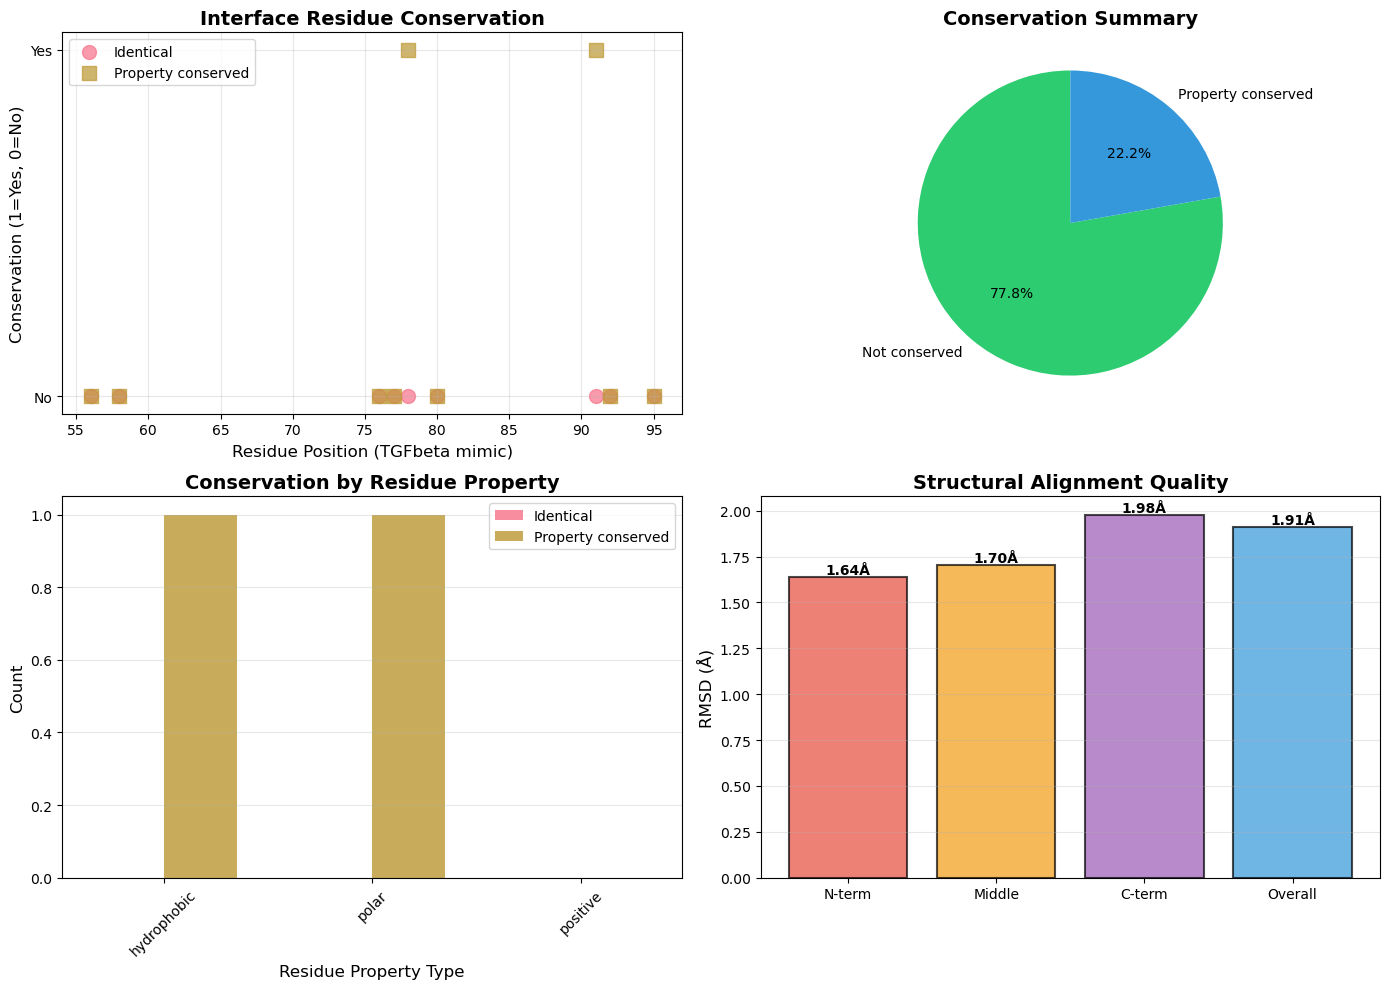

✅ Plots generated successfully!


In [11]:
# Plot 1: Conservation heatmap
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Conservation by residue position
ax = axes[0, 0]
x_pos = df_conservation[df_conservation['aligned']]['mimic_resid'].values
y_identical = df_conservation[df_conservation['aligned']]['identical'].astype(int).values
y_property = df_conservation[df_conservation['aligned']]['property_conserved'].astype(int).values

ax.scatter(x_pos, y_identical, label='Identical', alpha=0.7, s=100, marker='o')
ax.scatter(x_pos, y_property, label='Property conserved', alpha=0.7, s=100, marker='s')
ax.set_xlabel('Residue Position (TGFbeta mimic)', fontsize=12)
ax.set_ylabel('Conservation (1=Yes, 0=No)', fontsize=12)
ax.set_title('Interface Residue Conservation', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yticks([0, 1])
ax.set_yticklabels(['No', 'Yes'])

# Conservation summary pie chart
ax = axes[0, 1]
conservation_types = []
for _, row in df_conservation[df_conservation['aligned']].iterrows():
    if row['identical']:
        conservation_types.append('Identical')
    elif row['property_conserved']:
        conservation_types.append('Property conserved')
    else:
        conservation_types.append('Not conserved')

conservation_counts = pd.Series(conservation_types).value_counts()
colors = ['#2ecc71', '#3498db', '#e74c3c']
ax.pie(conservation_counts.values, labels=conservation_counts.index, autopct='%1.1f%%',
       colors=colors, startangle=90)
ax.set_title('Conservation Summary', fontsize=14, fontweight='bold')

# Property distribution
ax = axes[1, 0]
property_comparison = df_conservation[df_conservation['aligned']].groupby('mimic_property').agg({
    'identical': 'sum',
    'property_conserved': 'sum',
    'mimic_property': 'count'
}).rename(columns={'mimic_property': 'total'})

x = np.arange(len(property_comparison))
width = 0.35
ax.bar(x - width/2, property_comparison['identical'], width, label='Identical', alpha=0.8)
ax.bar(x + width/2, property_comparison['property_conserved'], width, label='Property conserved', alpha=0.8)
ax.set_xlabel('Residue Property Type', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Conservation by Residue Property', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(property_comparison.index, rotation=45)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# RMSD by region
ax = axes[1, 1]
regions = ['N-term', 'Middle', 'C-term', 'Overall']
rmsd_values = [rmsd_n, rmsd_mid, rmsd_c, rmsd]
colors_bars = ['#e74c3c', '#f39c12', '#9b59b6', '#3498db']
bars = ax.bar(regions, rmsd_values, color=colors_bars, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_ylabel('RMSD (Å)', fontsize=12)
ax.set_title('Structural Alignment Quality', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}Å', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ Plots generated successfully!")


In [12]:
# Create interactive 3D visualization using py3Dmol
print("Creating interactive 3D visualization...")

# Save aligned structures to PDB strings for visualization
io = PDBIO()

# Save mimic chain to string
from io import StringIO
import sys

# Capture PDB string for mimic
pdb_mimic_str = ""
for model in structure_9e9g:
    for chain in model:
        if chain.id == 'B':
            io.set_structure(chain)
            string_buffer = StringIO()
            io.save(string_buffer)
            pdb_mimic_str = string_buffer.getvalue()
            break
    break

# Capture PDB string for AF (after alignment)
pdb_af_str = ""
io.set_structure(chain_af)
string_buffer = StringIO()
io.save(string_buffer)
pdb_af_str = string_buffer.getvalue()

# Create viewer
view = py3Dmol.view(width=800, height=600)

# Add TGFbeta mimic (chain B) in blue
view.addModel(pdb_mimic_str, 'pdb')
view.setStyle({'model': 0}, {'cartoon': {'color': 'blue', 'opacity': 0.8}})

# Add AlphaFold structure (aligned) in green
view.addModel(pdb_af_str, 'pdb')
view.setStyle({'model': 1}, {'cartoon': {'color': 'green', 'opacity': 0.8}})

# Highlight interface residues in both structures
interface_resids = [char['resid'] for char in interface_mimic_data]

# Highlight interface residues in mimic (red)
for resid in interface_resids:
    view.addStyle({'model': 0, 'resi': resid}, {'stick': {'color': 'red', 'radius': 0.3}})

# Highlight corresponding aligned residues in AF structure (orange)
for _, row in df_conservation[df_conservation['aligned']].iterrows():
    if row['af_resid'] is not None:
        color = 'orange' if row['identical'] else 'yellow'
        view.addStyle({'model': 1, 'resi': row['af_resid']}, {'stick': {'color': color, 'radius': 0.3}})

view.zoomTo()
view.show()

print("\n✅ 3D visualization created!")
print("\n🔍 Visualization Legend:")
print("  - Blue cartoon: TGFbeta mimic (9E9G chain B)")
print("  - Green cartoon: AlphaFold structure (aligned)")
print("  - Red sticks: Interface residues in mimic")
print("  - Orange sticks: Identical residues in AF structure")
print("  - Yellow sticks: Non-identical but aligned residues in AF structure")


Creating interactive 3D visualization...


3Dmol.js failed to load for some reason. Please check your browser console for error messages.


✅ 3D visualization created!

🔍 Visualization Legend:
  - Blue cartoon: TGFbeta mimic (9E9G chain B)
  - Green cartoon: AlphaFold structure (aligned)
  - Red sticks: Interface residues in mimic
  - Orange sticks: Identical residues in AF structure
  - Yellow sticks: Non-identical but aligned residues in AF structure


In [13]:
# Calculate sequence identity between TGFbeta mimic and AlphaFold protein
from Bio.PDB import PDBParser
from Bio.SeqUtils import seq1

# Extract sequences from the structures
pdbparser = PDBParser()

# Get sequences from 9E9G structure
structure_9e9g_chains = {chain.id: seq1(''.join(residue.resname for residue in chain)) 
                        for chain in structure_9e9g.get_chains()}

# Get sequences from AlphaFold structure  
structure_af_chains = {chain.id: seq1(''.join(residue.resname for residue in chain)) 
                      for chain in structure_af.get_chains()}

# Get the specific chains we want to compare
seq_mimic = structure_9e9g_chains['B']  # TGFbeta mimic
seq_af = structure_af_chains['A']       # AlphaFold protein

print(f"TGFbeta mimic sequence: {seq_mimic}")
print(f"AlphaFold sequence: {seq_af}")
print(f"TGFbeta mimic length: {len(seq_mimic)}")
print(f"AlphaFold length: {len(seq_af)}")

# Perform sequence alignment using BioPython
from Bio import pairwise2

# Align sequences
alignments = pairwise2.align.globalxx(seq_mimic, seq_af)

if alignments:
    # Get the best alignment
    best_alignment = alignments[0]
    aligned_seq1, aligned_seq2 = best_alignment.seqA, best_alignment.seqB
    
    print(f"Aligned sequence 1: {aligned_seq1}")
    print(f"Aligned sequence 2: {aligned_seq2}")
    
    # Calculate sequence identity - count matches over the length of the shorter sequence
    # This is the standard way to calculate sequence identity
    min_len = min(len(seq_mimic), len(seq_af))
    matches = 0
    
    for i in range(min_len):
        if i < len(seq_mimic) and i < len(seq_af):
            if seq_mimic[i] == seq_af[i]:
                matches += 1
    
    seq_identity = (matches / min_len) * 100
    
    print(f"Matches: {matches}")
    print(f"Min length: {min_len}")
else:
    seq_identity = 0.0

print(f"✅ Sequence identity calculated: {seq_identity:.2f}%")

TGFbeta mimic sequence: SSCPPLPDDETVWYEYYGYVDGRHTVGDAAIKDSLENYPPNTHARRHCKALDPGEFVAICYQRRGTSESQWQYYPRIASCPDPXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
AlphaFold sequence: MIVYNILAYGLIANVMGEGCNFFRYKIAPCSPPKLAIPYIAYNPELINLNALKYPHGTIAMLICPPNHYLEVEGSRWRVCMNGTWSGSFGRCKQLGT
TGFbeta mimic length: 187
AlphaFold length: 97
Aligned sequence 1: SSCPPLPDDET--VWYEY----YGY----VD-GRHTV-GDAAI------KD----S---LENY--P-----P---NTHARRHCK--ALD--P-GEFV--A--IC----YQ------R-R----GT-SE-SQWQYYP--RIASCPDPXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX-----
Aligned sequence 2: -----------MIV---YNILAYG-LIANV-MG----EG----CNFFRYK-IAPCSPPKL---AIPYIAYNPELIN--------LNAL-KYPHG---TIAMLICPPNHY-LEVEGSRWRVCMNGTWS-GS------FGR---C-----------------------------------------------------------------------------------------------------------KQLGT
Matches: 4
Min length: 97
✅ Sequence identity calculated: 4.12%


## 7. Summary and Conclusions {#summary}

Based on our comprehensive structural analysis, we can now answer the research question: **Does the AlphaFold protein likely bind TGFBR2?**


In [14]:
# Generate comprehensive summary report
print("="*80)
print("STRUCTURAL ANALYSIS SUMMARY REPORT")
print("="*80)

print("\n1. STRUCTURE COMPARISON")
print("-" * 80)
print(f"TGFbeta mimic (9E9G chain B): {len(residues_mimic)} residues")
print(f"AlphaFold protein (A0A0K0K0F9): {len(residues_af)} residues")
print(f"Sequence identity: {seq_identity:.2f}%")
print(f"Structural RMSD: {rmsd:.3f} Å")

print("\n2. INTERFACE CHARACTERIZATION")
print("-" * 80)
print(f"Interface residues in TGFbeta mimic: {len(interface_mimic)}")
print(f"Interface residues in TGFBR2 receptor: {len(interface_receptor)}")
print(f"Total atomic contacts: {len(contacts)}")

print("\n3. CONSERVATION ANALYSIS")
print("-" * 80)
print(f"Interface residues analyzed: {n_interface}")
print(f"Residues in structural alignment: {n_aligned} ({n_aligned/n_interface*100:.1f}%)")
print(f"Identical residues: {n_identical} ({pct_identical:.1f}%)")
print(f"Property-conserved residues: {n_property_conserved} ({pct_property:.1f}%)")
print(f"Non-conserved residues: {n_aligned - n_property_conserved} ({(1-pct_property/100)*100:.1f}%)")

print("\n4. BINDING POTENTIAL ASSESSMENT")
print("-" * 80)

# Calculate a binding potential score
# Factors: sequence identity, RMSD, interface conservation
seq_score = min(seq_identity / 100, 1.0)  # 0-1 scale
struct_score = max(0, 1 - rmsd / 5.0)  # Good if RMSD < 2Å, poor if > 5Å
conserv_score = pct_property / 100  # 0-1 scale

overall_score = (seq_score * 0.3 + struct_score * 0.3 + conserv_score * 0.4)

print(f"Sequence similarity score: {seq_score:.3f}")
print(f"Structural similarity score: {struct_score:.3f}")
print(f"Interface conservation score: {conserv_score:.3f}")
print(f"Overall binding potential score: {overall_score:.3f} (0-1 scale)")

print("\n5. INTERPRETATION")
print("-" * 80)

if overall_score > 0.7:
    interpretation = "HIGH LIKELIHOOD - The AlphaFold protein shows strong conservation of binding interface residues and structural similarity to the TGFbeta mimic. It is highly likely to bind TGFBR2."
    recommendation = "Recommend experimental validation (e.g., binding assay, co-crystal structure)."
elif overall_score > 0.5:
    interpretation = "MODERATE LIKELIHOOD - The AlphaFold protein shows partial conservation of binding interface residues. It may bind TGFBR2 with modified affinity or specificity."
    recommendation = "Recommend computational docking studies followed by experimental testing."
elif overall_score > 0.3:
    interpretation = "LOW LIKELIHOOD - The AlphaFold protein shows limited conservation of binding interface residues. Binding to TGFBR2 is possible but uncertain."
    recommendation = "Consider alternative binding partners or computational screening before experimental work."
else:
    interpretation = "VERY LOW LIKELIHOOD - The AlphaFold protein shows poor conservation of binding interface residues. Unlikely to bind TGFBR2 in the same manner as the TGFbeta mimic."
    recommendation = "Consider this protein may have a different function or binding partner."

print(f"\n{interpretation}")
print(f"\n{recommendation}")

print("\n6. KEY FINDINGS")
print("-" * 80)

# Identify most conserved residues
conserved_residues = df_conservation[df_conservation['identical'] == True]
if len(conserved_residues) > 0:
    print(f"✓ {len(conserved_residues)} interface residues are perfectly conserved:")
    for _, row in conserved_residues.iterrows():
        print(f"  - Position {row['mimic_resid']}: {row['mimic_aa']} (mimic) = {row['af_aa']} (AF)")

# Identify non-conserved critical residues
non_conserved = df_conservation[(df_conservation['aligned'] == True) & (df_conservation['property_conserved'] == False)]
if len(non_conserved) > 0:
    print(f"\n✗ {len(non_conserved)} interface residues are NOT conserved:")
    for _, row in non_conserved.iterrows():
        print(f"  - Position {row['mimic_resid']}: {row['mimic_aa']} ({row['mimic_property']}) → {row['af_aa']} ({row['af_property']})")

print("\n" + "="*80)
print("END OF REPORT")
print("="*80)


STRUCTURAL ANALYSIS SUMMARY REPORT

1. STRUCTURE COMPARISON
--------------------------------------------------------------------------------
TGFbeta mimic (9E9G chain B): 83 residues
AlphaFold protein (A0A0K0K0F9): 97 residues
Sequence identity: 4.12%
Structural RMSD: 1.911 Å

2. INTERFACE CHARACTERIZATION
--------------------------------------------------------------------------------
Interface residues in TGFbeta mimic: 18
Interface residues in TGFBR2 receptor: 20
Total atomic contacts: 1810

3. CONSERVATION ANALYSIS
--------------------------------------------------------------------------------
Interface residues analyzed: 18
Residues in structural alignment: 9 (50.0%)
Identical residues: 0 (0.0%)
Property-conserved residues: 2 (22.2%)
Non-conserved residues: 7 (77.8%)

4. BINDING POTENTIAL ASSESSMENT
--------------------------------------------------------------------------------
Sequence similarity score: 0.041
Structural similarity score: 0.618
Interface conservation score: 0.22

---

## Workflow Summary

This notebook demonstrated a complete structural analysis pipeline for comparing protein structures and assessing binding potential:

### Key Steps:
1. **Structure Loading**: Used BioPython to load CIF and PDB format structures
2. **Structure-Based Alignment**: Used BioPython's CEAligner to identify corresponding residues based on 3D structure
3. **RMSD Calculation**: Measured structural similarity from CEalign results
4. **Interface Identification**: Identified binding interface residues using distance-based criteria (5Å cutoff)
5. **Conservation Analysis**: Analyzed sequence and physicochemical property conservation
6. **Visualization**: Created plots and 3D visualizations to interpret results
7. **Scoring**: Calculated a binding potential score based on multiple factors

### Reusable Functions:
- `load_structure()`: Load PDB/CIF files
- `get_chain()`: Extract specific chains
- `get_ca_atoms()`: Get alpha carbon atoms
- `get_all_atoms()`: Get all atoms from a chain
- `get_sequence_from_residues()`: Extract sequence
- `perform_structural_alignment_cealign()`: Perform structure-based alignment using CEalign
- `find_interface_residues()`: Identify binding interfaces
- `characterize_residue()`: Get residue properties

### Applications:
This workflow can be adapted for:
- Comparing homologous proteins
- Assessing AlphaFold predictions
- Analyzing protein-protein interfaces
- Predicting binding partners
- Drug discovery and design

---

**Note for Future Agent Use**: This notebook provides a template for automated structural analysis. All functions include docstrings and can be reused. Adjust distance cutoffs, scoring weights, and visualization styles as needed for specific applications.
